# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Maderazo Andre Rafael Cosme



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [20]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import RandomizedSearchCV

print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 2.3.3
NumPy: 2.4.4
matplotlib: 3.10.8
scikit-learn: 1.8.0


# 1. Business Understanding
Business Understanding

Educational institutions may not always identify students who are at risk of dropping out early enough to provide support.

The aim of this project is to develop a machine-learning model that predicts whether a student is likely to:

- Drop out
- Remain enrolled
- Graduate

This is a multiclass classification problem because the model predicts one of three possible outcomes.

The prediction will be made using information available by the end of Semester 1. Semester 2 variables will be removed because they would not be available at the time of prediction.

The intended users are student-support officers and academic advisers. The model is designed as an early-warning support tool and should not be used to make automatic decisions about students.

# 2. Data Understanding

## 2.1 Load dataset

### Dataset Overview

The dataset contains 4,424 student records and 37 variables. Each row represents one student, while the columns contain demographic, financial, admission and academic information.

The target variable is **Target**, which contains three possible student outcomes:

- **Dropout**
- **Enrolled**
- **Graduate**

The objective is to predict the final student outcome using information that would be available by the end of Semester 1.

In [3]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv("data.csv")

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2.2 Summary Statistics

### Summary Statistics Interpretation

The descriptive statistics show that the variables in the dataset use different measurement scales. Some variables are binary indicators, some are categorical values stored as numerical codes, and others are continuous measurements such as grades, age and economic indicators.

The dataset contains no missing values and no duplicate rows. Numerical variables may require scaling for models that are sensitive to differences in feature magnitude, while categorical codes should be treated as categories during preprocessing.

In [4]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [5]:
## Check for missing data
print("\nTotal missing values:")
print(df.isnull().sum().sum())

## Check for duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())


Total missing values:
0

Duplicate rows:
0


In [6]:
## Describe data distribution
print("\nTarget distribution:")
print(df["Target"].value_counts())


Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

### Semester 1 Grade Distribution Interpretation

The histogram shows the distribution of average Semester 1 grades across the student population.

A concentration of students appears within the middle grade range, while some students have very low or zero grades. These low values may represent students who performed poorly, did not complete assessments or disengaged during the semester.

Semester 1 grade is expected to be an important predictor because it provides a direct measure of early academic performance.

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

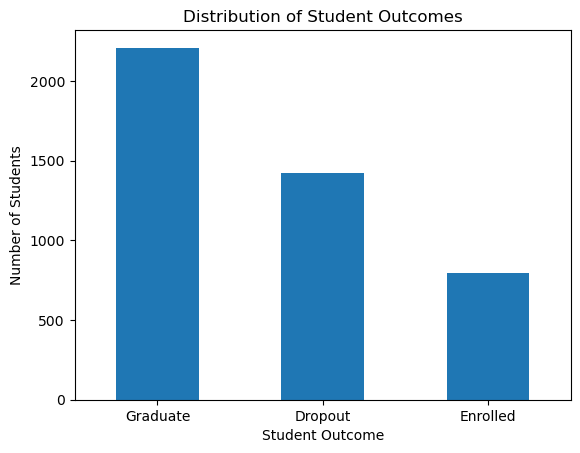

In [7]:
## Understanding distribution of target
target_counts = df["Target"].value_counts()

display(target_counts)

target_counts.plot(kind="bar")

plt.title("Distribution of Student Outcomes")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

### 2.3.1.2 Understanding distribution of features

### Semester 1 Grade Distribution Interpretation

The histogram shows the distribution of students' average Semester 1 grades.

Most students are concentrated within the middle grade range, while a smaller number of students have very low or zero grades. These low values may indicate poor academic performance, incomplete assessments or early disengagement from studies.

Semester 1 grade is likely to be an important predictor of student outcome because it directly represents early academic performance. Students with stronger Semester 1 grades may be more likely to graduate, while students with lower grades may face a greater risk of remaining enrolled or dropping out.

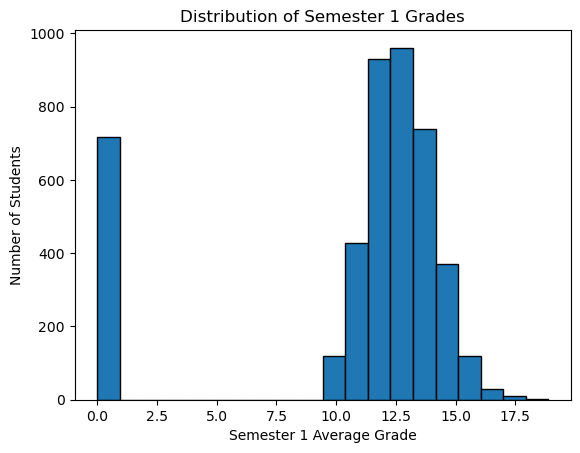

In [8]:
## Understanding distribution of features
df["Curricular units 1st sem (grade)"].plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Semester 1 Grades")
plt.xlabel("Semester 1 Average Grade")
plt.ylabel("Number of Students")

plt.show()

### 2.3.2 Understanding relationship between variables

### Approved Units and Student Outcome

The average number of approved Semester 1 curricular units differs clearly across the three student outcomes.

Graduate students have the highest average number of approved units, followed by students who remain Enrolled. Dropout students have the lowest average number of approved units.

This relationship suggests that early academic progress is strongly associated with a student's final outcome. The number of approved Semester 1 units may therefore be an important predictor for distinguishing between Graduate, Enrolled and Dropout students.

Target
Dropout     2.551724
Enrolled    4.318640
Graduate    6.232232
Name: Curricular units 1st sem (approved), dtype: float64

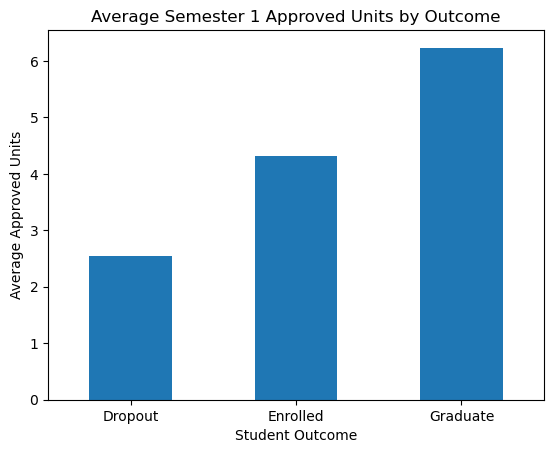

In [9]:
## Understanding relationship between variables
approved_by_outcome = (
    df.groupby("Target")[
        "Curricular units 1st sem (approved)"
    ]
    .mean()
)

display(approved_by_outcome)

approved_by_outcome.plot(kind="bar")

plt.title("Average Semester 1 Approved Units by Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Average Approved Units")
plt.xticks(rotation=0)

plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

### Data Cleaning and Feature Engineering

A copy of the original dataset was created before making any changes so that the raw data remained unchanged.

Duplicate rows were checked and removed where necessary. Semester 2 variables were also removed because the prediction is intended to be made at the end of Semester 1. Including Semester 2 information would introduce data leakage because those values would not be available at the intended prediction time.

Two new features were created from the Semester 1 academic variables:

- **Semester 1 Pass Rate** measures the proportion of enrolled curricular units that were approved.
- **Semester 1 Completion Gap** measures the difference between enrolled and approved curricular units.

These engineered features provide clearer measures of a student's early academic performance and may help the classification models distinguish between Dropout, Enrolled and Graduate outcomes.

In [10]:
## Clean data
# Create a separate copy for modelling
model_df = df.copy()

# Remove duplicate rows
model_df = model_df.drop_duplicates().reset_index(drop=True)

print("Original number of rows:", len(df))
print("Rows after removing duplicates:", len(model_df))

# Find all Semester 2 columns
semester_2_columns = [
    column
    for column in model_df.columns
    if "2nd sem" in column.lower()
]

print("\nSemester 2 columns removed:")

for column in semester_2_columns:
    print("-", column)

# Remove Semester 2 columns
model_df = model_df.drop(columns=semester_2_columns)

# Create simple Semester 1 performance features
enrolled_units = model_df[
    "Curricular units 1st sem (enrolled)"
]

approved_units = model_df[
    "Curricular units 1st sem (approved)"
]

model_df["Sem1 Pass Rate"] = np.where(
    enrolled_units > 0,
    approved_units / enrolled_units,
    0
)

model_df["Sem1 Completion Gap"] = (
    enrolled_units - approved_units
)

display(
    model_df[
        ["Sem1 Pass Rate", "Sem1 Completion Gap"]
    ].head()
)

print("\nNew dataset shape:", model_df.shape)

Original number of rows: 4424
Rows after removing duplicates: 4424

Semester 2 columns removed:
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)


,Sem1 Pass Rate,Sem1 Completion Gap
0,0.000000,0
1,1.000000,0
2,0.000000,6
3,1.000000,0
4,0.833333,1



New dataset shape: (4424, 33)


## 3.2 Train-Test Split

### Train-Test Split Explanation

The input features were stored in `X`, while the student outcome was
stored in `y`.

The dataset was divided into 80% training data and 20% testing data.
The training set will be used to develop the models, while the test set
will be used to evaluate performance on unseen student records.

Stratification was used to preserve the proportions of Dropout, Enrolled
and Graduate students in both sets. A fixed random state was used to make
the split reproducible.

In [11]:
## Split data into train set and test set
# Separate the predictors from the target
X = model_df.drop(columns="Target")
y = model_df["Target"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the split
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training rows: 3539
Testing rows: 885

Training target distribution:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Testing target distribution:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64


### Data Preprocessing

The predictor variables were separated into categorical and numerical features.

Several variables are stored as numbers but represent categories, including course, application mode, marital status and previous qualification. These variables will be transformed using one-hot encoding so that the models do not incorrectly interpret the category codes as continuous measurements.

Numerical variables will be standardised using `StandardScaler`. Standardisation places numerical features on comparable scales and is particularly important for models such as Logistic Regression.

The preprocessing steps were combined using a `ColumnTransformer`. This transformer will be included inside each machine-learning pipeline and fitted only on the training data, helping to prevent data leakage.

In [12]:
# Variables that contain categories represented by numerical codes
categorical_candidates = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nationality",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

# Keep only columns that exist in this dataset
categorical_features = [
    column for column in categorical_candidates
    if column in X_train.columns
]

# All remaining columns are treated as numerical
numeric_features = [
    column for column in X_train.columns
    if column not in categorical_features
]

print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numeric_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Number of categorical features: 17
Number of numerical features: 15

Categorical features:
['Marital status', 'Application mode', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nationality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Numerical features:
['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Sem1 Pass Rate', 'Sem1 Completion Gap']


### Data Preprocessing

The predictor variables were separated into categorical and numerical features.

Several variables are stored as numbers but represent categories, including course, application mode, marital status and previous qualification. These variables will be transformed using one-hot encoding so that the models do not incorrectly interpret the category codes as continuous measurements.

Numerical variables will be standardised using `StandardScaler`. Standardisation places numerical features on comparable scales and is particularly important for models such as Logistic Regression.

The preprocessing steps were combined using a `ColumnTransformer`. This transformer will be included inside each machine-learning pipeline and fitted only on the training data, helping to prevent data leakage.

In [13]:
# Preprocessing for numerical variables
numeric_transformer = StandardScaler()

# Preprocessing for categorical variables
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# 4. Modelling

### 4.2 Train Model

### Baseline Model and Model Comparison

Three classification models were evaluated:

- **Dummy Classifier** was used as a baseline and predicted the most frequent outcome.
- **Logistic Regression** provided a relatively simple and interpretable classification model.
- **Random Forest** provided a more flexible ensemble model capable of learning non-linear relationships.

The models were evaluated using five-fold stratified cross-validation on the training set. Stratification preserved the proportions of Graduate, Dropout and Enrolled students within each fold.

Macro F1-score was used as the primary comparison metric because the target classes are imbalanced and this metric gives equal importance to all three outcomes. Accuracy and Dropout recall were also recorded.

The test set was not used during this comparison. It remains reserved for the final evaluation of the selected model.

In [14]:
# Create the baseline model
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

# Create the Logistic Regression model
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Create the Random Forest model
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

models = {
    "Dummy Classifier": dummy_pipeline,
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline
}

print("Models created successfully.")

Models created successfully.


In [15]:
# Calculate recall specifically for the Dropout class
def dropout_recall(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=["Dropout"],
        average="macro",
        zero_division=0
    )


dropout_recall_scorer = make_scorer(dropout_recall)

# Five-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "dropout_recall": dropout_recall_scorer
}

In [16]:
# Initialise and train model
model_results = []

for model_name, model_pipeline in models.items():

    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    model_results.append({
        "Model": model_name,
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "Mean Macro F1": scores["test_macro_f1"].mean(),
        "Mean Dropout Recall": scores["test_dropout_recall"].mean()
    })

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Mean Macro F1",
    ascending=False
).reset_index(drop=True)

display(results_df.round(3))

,Model,Mean Accuracy,Mean Macro F1,Mean Dropout Recall
0,Logistic Regression,0.721,0.678,0.710
1,Random Forest,0.752,0.658,0.765
2,Dummy Classifier,0.499,0.222,0.000


### Model Comparison Interpretation

Logistic Regression achieved the highest mean Macro F1-score of **0.678**, with a mean accuracy of **0.721** and a mean Dropout recall of **0.710**.

Random Forest achieved the highest mean accuracy of **0.752** and the highest Dropout recall of **0.765**. However, its Macro F1-score of **0.658** was lower than that of Logistic Regression, indicating that its performance was less balanced across the three outcome classes.

Both machine-learning models performed substantially better than the Dummy Classifier, which achieved a Macro F1-score of only **0.222**. This demonstrates that the models learned meaningful relationships from the student data rather than simply predicting the majority class.

Since Macro F1-score was selected as the primary evaluation metric, Logistic Regression was selected for hyperparameter tuning. Random Forest remains a useful comparison because of its stronger accuracy and Dropout recall.

In [23]:
# Hyperparameters to test for Logistic Regression
logistic_param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__solver": ["lbfgs", "liblinear", "saga"],
    "model__class_weight": [None, "balanced"]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [26]:
random_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_param_grid,
    n_iter=12,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(random_search.best_score_, 3))

tuning_results = pd.DataFrame(
    random_search.cv_results_
)

tuning_results = tuning_results[
    [
        "params",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
).reset_index(drop=True)

display(tuning_results.head().round(3))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\andre\anaconda3\envs\mldp\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\andre\anaconda3\envs\mldp\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\andre\anaconda3\envs\mldp\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\andre\anaconda3\envs\mldp\Lib\site-packages\sklearn\pipeline.py", line 6

Best parameters:
{'model__solver': 'saga', 'model__class_weight': 'balanced', 'model__C': 0.1}

Best cross-validation Macro F1:
0.685


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__solver': 'saga', 'model__class_weight...",0.720,0.685,0.019,1
1,"{'model__solver': 'lbfgs', 'model__class_weigh...",0.720,0.685,0.020,2
2,"{'model__solver': 'lbfgs', 'model__class_weigh...",0.733,0.678,0.020,3
3,"{'model__solver': 'saga', 'model__class_weight...",0.733,0.678,0.019,4
4,"{'model__solver': 'lbfgs', 'model__class_weigh...",0.737,0.669,0.023,5


### Hyperparameter Tuning

Logistic Regression was selected for hyperparameter tuning because it achieved the highest mean Macro F1-score during the initial model comparison.

`RandomizedSearchCV` was used to test different values for the regularisation strength, optimisation solver and class-weight setting. The search used five-fold stratified cross-validation and Macro F1-score as the optimisation metric.

The preprocessing transformer remained inside the model pipeline. Therefore, preprocessing was fitted separately within each cross-validation fold, reducing the risk of data leakage.

The test set was not used during hyperparameter tuning and remained reserved for the final evaluation.

# 5. Model Evaluation

In [17]:
## Evaluate model


In [18]:
## New data

## Predict


## Iterative model development


In [19]:
## Further feature engineering / feature selection